# A data analysis product for loan issues
Data sets: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset (26.Apri.2026)from kaggle

In real life, when individuals apply for loans from financial institutions, they are influenced by a variety of real factors such as personal income level, credit status, debt ratio, job stability, asset conditions, and application qualifications. As a result, the loan approval outcomes vary significantly among different groups of people. The issue of whether a loan can be approved will be more conveniently resolved through a classification set.. The product will predict whether the borrower can obtain the loan based on the information provided by the lender.For ordinary people with loan needs, they can proactively assess their approval probability and avoid damage to their credit records. At the same time, banks and financial institutions can also reduce invalid applications and lower the pressure of risk control, achieving mutual benefits

In [1]:
import warnings
from pathlib import Path

# data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV # for splitting data and hyperparameter tuning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

print('done')

done


# Load the dataset

In [2]:
file_path = Path("loan_approval_dataset.csv")
df = pd.read_csv(file_path) # dataframe
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
dataset_name = "Loan Approval Dataset"
target_name = "loan_status"
print("当前数据集：", dataset_name)
print("数据集形状：", df.shape)
df.head()

当前数据集： Loan Approval Dataset
数据集形状： (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Basic inspection

In [3]:
print("数据基本信息：")
df.info()

print("缺失值统计：")
print(df.isna().sum()) 

print("重复值数量：")
print(len(df[df.duplicated()]))

try:
    print("描述性统计：")
    display(df.describe())
except:
    print(df.describe())

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
缺失值统计：
loan_id        

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# Exploratory Data Analysis
The target variable is `loan status`, which consists of two categories: `Approved` and `Rejected `.

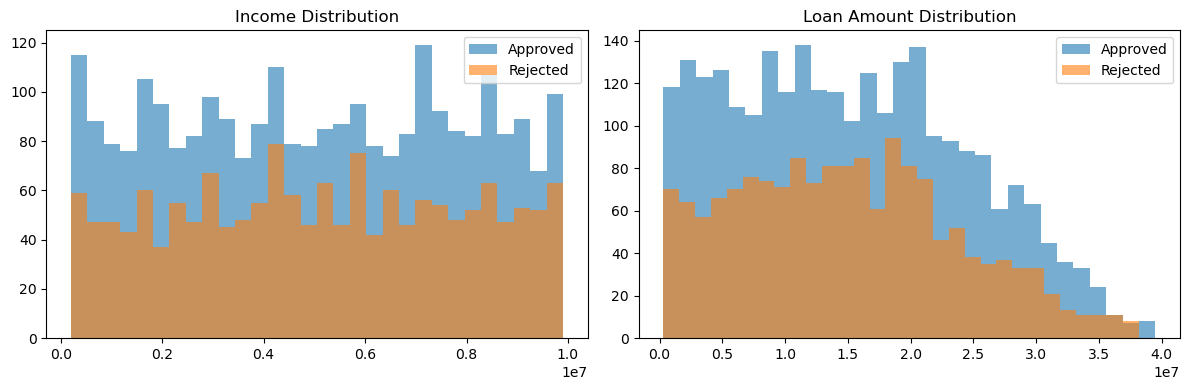

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df.loc[df["loan_status"] == "Approved", "income_annum"], bins=30, alpha=0.6, label="Approved")
axes[0].hist(df.loc[df["loan_status"] == "Rejected", "income_annum"], bins=30, alpha=0.6, label="Rejected")
axes[0].set_title("Income Distribution")
axes[0].legend()

axes[1].hist(df.loc[df["loan_status"] == "Approved", "loan_amount"], bins=30, alpha=0.6, label="Approved")
axes[1].hist(df.loc[df["loan_status"] == "Rejected", "loan_amount"], bins=30, alpha=0.6, label="Rejected")
axes[1].set_title("Loan Amount Distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

The histogram illustrates the distributions of `income_annum` and `loan_amount` across different loan approval outcomes. If approved applicants are generally concentrated in the higher income ranges, it indicates that annual income may exert a **positive impact** on loan approval decisions.

In contrast, if rejected applicants are predominantly distributed within high loan amount brackets, or densely clustered in the segment with low annual income but high requested loan amounts, the mismatch between loan amount and income level is likely to affect approval results.

A high degree of distribution overlap between the Approved and Rejected groups suggests that income and loan amount alone are insufficient to fully distinguish loan outcomes. Nevertheless, significant discrepancies in distribution centers, tail characteristics and concentration intervals demonstrate that these two variables remain critical predictive features.

This also implies that subsequent optimization steps can be implemented, including data scaling, outlier detection, and the construction of ratio-based features correlated with income and loan amount.

# Variable type determination

In [5]:
dtype_df = df.dtypes.astype(str).to_frame(name="dtype")
dtype_df = dtype_df.reset_index().rename(columns={"index": "column"})
dtype_df

,column,dtype
0,loan_id,int64
1,no_of_dependents,int64
2,education,object
3,self_employed,object
4,income_annum,int64
5,loan_amount,int64
6,loan_term,int64
7,cibil_score,int64
8,residential_assets_value,int64
9,commercial_assets_value,int64


In [6]:
numeric_cols_detected = df.select_dtypes(include="number").columns.tolist()
categorical_cols_detected = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("检测到的数值变量：")
print(numeric_cols_detected)
print("检测到的类别变量：")
print(categorical_cols_detected)


检测到的数值变量：
['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
检测到的类别变量：
['education', 'self_employed', 'loan_status']


# Pretreatment

In [7]:
df_processed = df.copy()
df_processed.columns = df_processed.columns.str.strip()
for col in df_processed.select_dtypes(include="object").columns:
    df_processed[col] = df_processed[col].str.strip()

numeric_cols = df_processed.select_dtypes(include=["int64", "float64"]).columns
df_processed[numeric_cols] = df_processed[numeric_cols].fillna(df_processed[numeric_cols].median())

missing_summary = df_processed.isna().sum()
print(missing_summary)

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


# Modeling data preparation
The units of different numerical variables can vary greatly. For instance, the order of magnitude of `income_annum` and `cibil_score` is completely different.
- Models like `Logistic Regression` are usually sensitive to the scale of features. If not standardized, columns with extremely large values may have a strong impact on the model training.
- After standardization, it becomes easier for different variables to participate in the training on similar scales.

In [8]:
df_processed["education"] = df_processed["education"].map({"Graduate": 1, "Not Graduate": 0})
df_processed["self_employed"] = df_processed["self_employed"].map({"Yes": 1, "No": 0})
df_processed["loan_status"] = df_processed["loan_status"].map({"Approved": 1, "Rejected": 0})

X = df_processed.drop(["loan_status", "loan_id"], axis=1)
y = df_processed["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

numeric_cols = [col for col in [
    "no_of_dependents", "income_annum", "loan_amount", "loan_term", "cibil_score",
    "residential_assets_value", "commercial_assets_value", "luxury_assets_value",
    "bank_asset_value", "total_assets_value", "financial_safety_ratio"
] if col in X_train.columns]

scaler = StandardScaler()
if len(numeric_cols) > 0:
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2988, 11)
X_test shape: (1281, 11)


In [9]:
model_lr = LogisticRegression(max_iter=300, random_state=42)
model_lr.fit(X_train, y_train)
print("Logistic Regression 训练完成")

Logistic Regression 训练完成


### No adjustable parameters
- This time, the focus is on process understanding and basic comparison.
- Simplify the tasks and start by observing the performance of the basic model.

# Evaluation of Logistic Regression

In [10]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Report": classification_report(y_test, y_pred),
    }
    print(model_name)
    print("Confusion Matrix:")
    print(result["Confusion Matrix"])
    print("Classification Report:")
    print(result["Report"])
    return result

In [11]:
results_lr = evaluate_model(model_lr, X_test, y_test, "Logistic Regression")

Logistic Regression
Confusion Matrix:
[[429  55]
 [ 48 749]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       484
           1       0.93      0.94      0.94       797

    accuracy                           0.92      1281
   macro avg       0.92      0.91      0.91      1281
weighted avg       0.92      0.92      0.92      1281



# Limitations
Although logistic regression is more interpretable than tree models, its coefficients can only reflect "linear correlation" and it is difficult to clearly explain to business personnel "why this customer was rejected", for example, it cannot directly state "whether it is because of low income, or high debt ratio" or the combined influence. 
Unable to handle complex feature interactions
In credit approval, many risks are generated by the combination of multiple features (such as "low income + high loan amount + poor credit record"), logistic regression has difficulty directly modeling such complex interactions. Unless you manually construct a large number of interaction terms, it will significantly increase the workload.

# conclusion
This loan approval prediction project analyzes a real-world financial dataset with 4,269 samples to forecast loan approval results. The full workflow includes data cleaning, exploratory data analysis, categorical feature encoding, data standardization, and train-test splitting. Key factors such as annual income, loan amount, credit score, employment and education status significantly affect loan decisions. A logistic regression model was built for binary classification, achieving strong overall performance with high accuracy, precision, recall and F1-score. The results prove that machine learning can effectively assist financial institutions in risk control and improve loan review efficiency. Meanwhile, the project also points out the limitations of the linear model and provides directions for further optimization with nonlinear algorithms and feature engineering.